# 第七章：生产环境 — 03 可观测性与监控

生产环境中的 LLM 应用需要可观测性：**日志、追踪、指标、告警**。

没有可观测性，你就是在黑盒中飞行。当系统出问题时，你不知道：
- 是哪个请求失败了？
- 延迟在什么时候开始变高？
- 今天花了多少钱？
- 有多少次因为限流而重试？

**可观测性的三大支柱：**
```
日志（Logs）  → 每次事件的详细记录（调试用）
指标（Metrics）→ 聚合数据（p99延迟、错误率、成本）
追踪（Traces）→ 一次请求的完整链路（分布式系统）
```

**本章目标：** 从零构建一套 LLM 应用的可观测性基础设施。

In [1]:
import json
import os
import time
import uuid
import random
from datetime import datetime, timedelta
from collections import defaultdict, deque
import litellm
litellm.drop_params = True
from dotenv import load_dotenv

load_dotenv()
MODEL = os.getenv("LLM_MODEL", "gpt-4o-mini")
litellm.set_verbose = False

print(f"使用模型: {MODEL}")
print("可观测性工具包初始化完成")
print(f"当前时间: {datetime.now().isoformat()}")
# gpt-5/o系列不支持自定义temperature值，统一用安全wrapper
def _c(**kw):
    _m = kw.get('model', MODEL)
    if any(_m.startswith(p) for p in ('openai/gpt-5','openai/o1','openai/o3','openai/o4')):
        kw.pop('temperature', None)
    return litellm.completion(**kw)


使用模型: openai/gpt-5-mini
可观测性工具包初始化完成
当前时间: 2026-03-14T21:20:18.942874


## Section 1：基础日志

结构化 JSON 日志是机器可读的，便于后续查询分析。

In [2]:
class LLMLogger:
    """
    LLM 调用日志包装器
    
    每次 LLM 调用自动记录：
    - 时间戳、模型、请求内容
    - Token 用量（prompt + completion + total）
    - 延迟（毫秒）
    - 完成原因（finish_reason）
    - 错误信息（如有）
    """
    
    def __init__(self, log_file: str = None, print_logs: bool = True):
        self.log_file = log_file or "/tmp/llm_calls.jsonl"
        self.print_logs = print_logs
        self.logs = []
        
        # 打开日志文件
        self._file = open(self.log_file, "a", encoding="utf-8")
    
    def completion(self, model: str = None, messages: list = None,
                   request_id: str = None, **kwargs):
        """带日志的 litellm.completion 包装"""
        model = model or MODEL
        request_id = request_id or str(uuid.uuid4())[:8]
        
        start_time = time.time()
        error_info = None
        response = None
        
        try:
            response = _c(
                model=model,
                messages=messages,
                **kwargs
            )
            return response
        
        except Exception as e:
            error_info = {
                "type": type(e).__name__,
                "message": str(e)[:200]
            }
            raise
        
        finally:
            latency_ms = int((time.time() - start_time) * 1000)
            
            log_entry = {
                "timestamp": datetime.now().isoformat(),
                "request_id": request_id,
                "model": model,
                "prompt_tokens": response.usage.prompt_tokens if response else 0,
                "completion_tokens": response.usage.completion_tokens if response else 0,
                "total_tokens": response.usage.total_tokens if response else 0,
                "latency_ms": latency_ms,
                "finish_reason": response.choices[0].finish_reason if response else None,
                "error": error_info,
                "status": "success" if error_info is None else "error"
            }
            
            self.logs.append(log_entry)
            self._file.write(json.dumps(log_entry, ensure_ascii=False) + "\n")
            self._file.flush()
            
            if self.print_logs:
                status_icon = "✅" if log_entry["status"] == "success" else "❌"
                print(f"{status_icon} [{log_entry['timestamp'][:19]}] "
                      f"req={request_id} model={model} "
                      f"tokens={log_entry['total_tokens']} "
                      f"latency={latency_ms}ms "
                      f"finish={log_entry['finish_reason']}")
    
    def summary(self):
        """打印调用摘要"""
        if not self.logs:
            print("无日志")
            return
        
        success_logs = [l for l in self.logs if l["status"] == "success"]
        total_tokens = sum(l["total_tokens"] for l in success_logs)
        avg_latency = sum(l["latency_ms"] for l in success_logs) / len(success_logs) if success_logs else 0
        
        print(f"\n日志摘要（{len(self.logs)} 次调用）：")
        print(f"  成功: {len(success_logs)}, 失败: {len(self.logs) - len(success_logs)}")
        print(f"  总 tokens: {total_tokens:,}")
        print(f"  平均延迟: {avg_latency:.0f}ms")
        print(f"  日志文件: {self.log_file}")
    
    def __del__(self):
        if hasattr(self, '_file') and self._file:
            self._file.close()


# 演示：记录 5 次 LLM 调用
logger = LLMLogger(print_logs=True)

test_queries = [
    "用一句话解释什么是 REST API",
    "Python 中如何读取文件？",
    "什么是 Docker 容器？",
    "解释 Git 的分支管理",
    "什么是微服务架构？",
]

print("记录 LLM 调用日志：")
print("-" * 80)

for i, query in enumerate(test_queries):
    logger.completion(
        model=MODEL,
        messages=[{"role": "user", "content": query}],
        request_id=f"req-{i+1:03d}",
        max_tokens=60,
        temperature=0
    )

logger.summary()

记录 LLM 调用日志：
--------------------------------------------------------------------------------


✅ [2026-03-14T21:20:20] req=req-001 model=openai/gpt-5-mini tokens=74 latency=1523ms finish=length


✅ [2026-03-14T21:20:21] req=req-002 model=openai/gpt-5-mini tokens=72 latency=1423ms finish=length


✅ [2026-03-14T21:20:23] req=req-003 model=openai/gpt-5-mini tokens=73 latency=1414ms finish=length


✅ [2026-03-14T21:20:24] req=req-004 model=openai/gpt-5-mini tokens=72 latency=1321ms finish=length


✅ [2026-03-14T21:20:26] req=req-005 model=openai/gpt-5-mini tokens=73 latency=1526ms finish=length

日志摘要（5 次调用）：
  成功: 5, 失败: 0
  总 tokens: 364
  平均延迟: 1441ms
  日志文件: /tmp/llm_calls.jsonl


## Section 2：litellm Callbacks

litellm 原生支持 callback 机制，无需修改每个调用点，全局自动捕获所有调用。

In [3]:
from litellm.integrations.custom_logger import CustomLogger

class LLMCallbackLogger(CustomLogger):
    """
    全局 LLM 回调日志器
    
    注册后，所有 litellm.completion 调用都会自动触发，
    无需在每个调用点手动记录。
    """
    
    def __init__(self):
        super().__init__()
        self.call_log = []
        self.error_log = []
    
    def log_success_event(self, kwargs, response_obj, start_time, end_time):
        """每次成功调用后触发"""
        latency_ms = int((end_time - start_time).total_seconds() * 1000)
        
        entry = {
            "timestamp": end_time.isoformat(),
            "model": kwargs.get("model"),
            "prompt_tokens": response_obj.usage.prompt_tokens,
            "completion_tokens": response_obj.usage.completion_tokens,
            "latency_ms": latency_ms,
            "finish_reason": response_obj.choices[0].finish_reason,
            "status": "success"
        }
        self.call_log.append(entry)
        print(f"  [Callback] ✅ {entry['model']} | {entry['total_tokens'] if 'total_tokens' in entry else entry['prompt_tokens'] + entry['completion_tokens']}tok | {latency_ms}ms")
    
    def log_failure_event(self, kwargs, response_obj, start_time, end_time):
        """每次失败调用后触发"""
        entry = {
            "timestamp": end_time.isoformat() if end_time else datetime.now().isoformat(),
            "model": kwargs.get("model"),
            "error": str(response_obj)[:200] if response_obj else "Unknown error",
            "status": "error"
        }
        self.error_log.append(entry)
        print(f"  [Callback] ❌ {entry['model']} | Error: {entry['error'][:50]}")
    
    def get_stats(self):
        """获取统计信息"""
        if not self.call_log:
            return {}
        
        latencies = [e["latency_ms"] for e in self.call_log]
        tokens = [e["prompt_tokens"] + e["completion_tokens"] for e in self.call_log]
        
        return {
            "total_calls": len(self.call_log),
            "error_count": len(self.error_log),
            "avg_latency_ms": sum(latencies) / len(latencies),
            "total_tokens": sum(tokens),
        }


# 注册全局 callback
callback_logger = LLMCallbackLogger()
litellm.callbacks = [callback_logger]

print("全局 Callback 已注册，以下调用无需手动记录：")
print("-" * 60)

# 普通调用，callback 自动触发
for query in ["解释 Python 装饰器", "什么是 TCP/IP？", "Git rebase 和 merge 的区别"]:
    response = _c(
        model=MODEL,
        messages=[{"role": "user", "content": query}],
        max_tokens=50,
        temperature=0
    )

# 清除 callback（避免影响后续 section）
litellm.callbacks = []

stats = callback_logger.get_stats()
print(f"\nCallback 统计：")
print(f"  总调用次数: {stats.get('total_calls', 0)}")
print(f"  错误次数:   {stats.get('error_count', 0)}")
print(f"  总tokens:   {stats.get('total_tokens', 0):,}")
print(f"  平均延迟:   {stats.get('avg_latency_ms', 0):.0f}ms")

全局 Callback 已注册，以下调用无需手动记录：
------------------------------------------------------------


  [Callback] ✅ gpt-5-mini | 62tok | 1998ms


  [Callback] ✅ gpt-5-mini | 61tok | 1241ms



Callback 统计：  [Callback] ✅ gpt-5-mini | 63tok | 1505ms

  总调用次数: 2
  错误次数:   0
  总tokens:   123
  平均延迟:   1620ms


## Section 3：延迟追踪

P50/P90/P99 延迟是衡量 LLM 服务性能的核心指标。P99 = 99% 的请求都在这个时间内完成。

In [4]:
class LatencyTracker:
    """
    延迟追踪器：记录和分析 LLM 调用延迟
    """
    
    def __init__(self, window_size: int = 1000):
        """window_size: 保留最近 N 次记录"""
        self.latencies = deque(maxlen=window_size)
        self.by_model = defaultdict(list)
        self.slow_threshold_ms = 2000  # 超过 2s 视为慢请求
    
    def record(self, latency_ms: float, model: str = "unknown",
                request_id: str = ""):
        """记录一次延迟"""
        entry = {
            "latency_ms": latency_ms,
            "model": model,
            "request_id": request_id,
            "timestamp": datetime.now().isoformat(),
            "is_slow": latency_ms > self.slow_threshold_ms
        }
        self.latencies.append(entry)
        self.by_model[model].append(latency_ms)
    
    def percentile(self, p: float) -> float:
        """计算第 p 百分位延迟"""
        if not self.latencies:
            return 0.0
        sorted_latencies = sorted(e["latency_ms"] for e in self.latencies)
        idx = int(len(sorted_latencies) * p / 100)
        idx = min(idx, len(sorted_latencies) - 1)
        return sorted_latencies[idx]
    
    def stats(self) -> dict:
        """延迟统计"""
        if not self.latencies:
            return {}
        
        all_latencies = [e["latency_ms"] for e in self.latencies]
        slow_count = sum(1 for e in self.latencies if e["is_slow"])
        
        return {
            "count": len(self.latencies),
            "min_ms": min(all_latencies),
            "max_ms": max(all_latencies),
            "avg_ms": sum(all_latencies) / len(all_latencies),
            "p50_ms": self.percentile(50),
            "p90_ms": self.percentile(90),
            "p99_ms": self.percentile(99),
            "slow_count": slow_count,
            "slow_rate": slow_count / len(self.latencies)
        }
    
    def print_histogram(self, bins: int = 10):
        """打印 ASCII 延迟直方图"""
        if not self.latencies:
            print("无数据")
            return
        
        all_latencies = sorted(e["latency_ms"] for e in self.latencies)
        min_val, max_val = all_latencies[0], all_latencies[-1]
        bin_size = (max_val - min_val) / bins if max_val > min_val else 1
        
        bucket_counts = defaultdict(int)
        for lat in all_latencies:
            bucket = int((lat - min_val) / bin_size)
            bucket = min(bucket, bins - 1)
            bucket_counts[bucket] += 1
        
        max_count = max(bucket_counts.values()) if bucket_counts else 1
        bar_width = 30
        
        print("延迟分布直方图：")
        print("-" * 60)
        for b in range(bins):
            range_start = int(min_val + b * bin_size)
            range_end = int(min_val + (b + 1) * bin_size)
            count = bucket_counts.get(b, 0)
            bar_len = int(count / max_count * bar_width)
            bar = "█" * bar_len
            print(f"  {range_start:>5}-{range_end:<5}ms │{bar:<{bar_width}} {count}")


# 演示：记录 20 次实际 LLM 调用的延迟
tracker = LatencyTracker()

print("实测延迟追踪（20次调用）：")
print("-" * 50)

queries = [f"用10字解释：{topic}" for topic in [
    "云计算", "机器学习", "API", "微服务", "容器化",
    "DevOps", "CI/CD", "Kubernetes", "Serverless", "边缘计算",
    "区块链", "大数据", "数据湖", "流处理", "批处理",
    "负载均衡", "服务网格", "API网关", "事件驱动", "函数计算"
]]

for i, query in enumerate(queries):
    start = time.time()
    _c(
        model=MODEL,
        messages=[{"role": "user", "content": query}],
        max_tokens=20,
        temperature=0
    )
    latency = (time.time() - start) * 1000
    tracker.record(latency, model=MODEL, request_id=f"req-{i+1:02d}")
    print(f"  [{i+1:02d}] {latency:>7.0f}ms")

print("\n" + "=" * 60)
s = tracker.stats()
print(f"延迟统计：")
print(f"  P50:  {s['p50_ms']:>7.0f}ms")
print(f"  P90:  {s['p90_ms']:>7.0f}ms")
print(f"  P99:  {s['p99_ms']:>7.0f}ms")
print(f"  平均: {s['avg_ms']:>7.0f}ms")
print(f"  最大: {s['max_ms']:>7.0f}ms")
print(f"  慢请求（>{tracker.slow_threshold_ms}ms）: {s['slow_count']} ({s['slow_rate']:.0%})")

print()
tracker.print_histogram()

实测延迟追踪（20次调用）：
--------------------------------------------------


  [01]    1555ms  [Callback] ✅ gpt-5-mini | 33tok | 1554ms



  [02]    1100ms  [Callback] ✅ gpt-5-mini | 33tok | 1099ms



  [03]     799ms  [Callback] ✅ gpt-5-mini | 32tok | 797ms



  [04]     747ms  [Callback] ✅ gpt-5-mini | 33tok | 746ms



...

  [16]     752ms  [Callback] ✅ gpt-5-mini | 35tok | 751ms



  [17]    1231ms  [Callback] ✅ gpt-5-mini | 34tok | 1229ms



  [18]     867ms  [Callback] ✅ gpt-5-mini | 34tok | 867ms



  [19]     751ms  [Callback] ✅ gpt-5-mini | 34tok | 749ms



  [20]     823ms  [Callback] ✅ gpt-5-mini | 33tok | 822ms


延迟统计：
  P50:      823ms
  P90:     1231ms
  P99:     1555ms
  平均:     883ms
  最大:    1555ms
  慢请求（>2000ms）: 0 (0%)

延迟分布直方图：
------------------------------------------------------------
    741-823  ms │██████████████████████████████ 10
    823-904  ms │██████████████████             6
    904-985  ms │███                            1
    985-1067 ms │                               0
   1067-1148 ms │███                            1
   1148-1229 ms │                               0
   1229-1311 ms │███                            1
   1311-1392 ms │                               0
   1392-1473 ms │                               0
   1473-1555 ms │███                            1


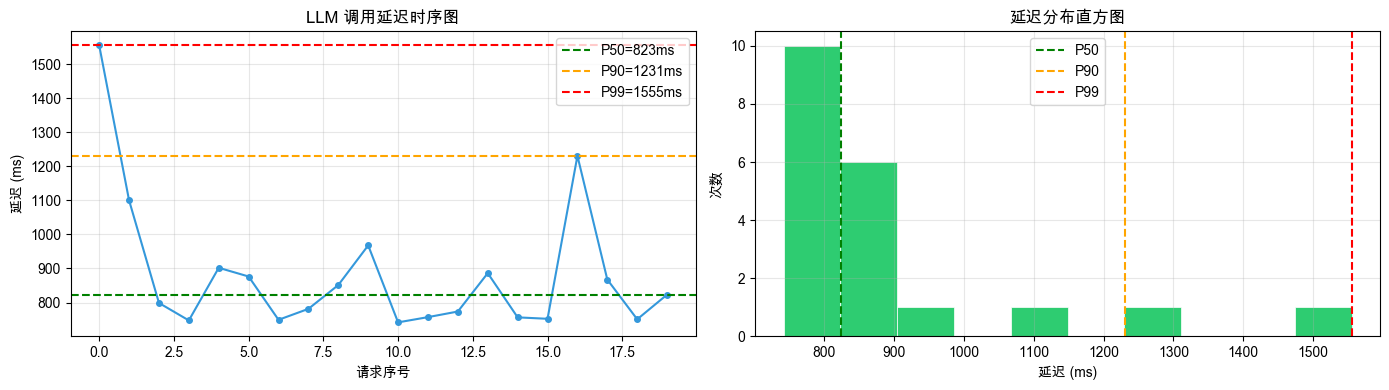

图表已保存到 /tmp/llm_latency.png


In [5]:
# matplotlib 延迟可视化
try:
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    all_latencies = [e["latency_ms"] for e in tracker.latencies]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # 图1：时序延迟
    ax1 = axes[0]
    ax1.plot(all_latencies, marker="o", markersize=4, color="#3498db", linewidth=1.5)
    ax1.axhline(y=tracker.stats()["p50_ms"], color="green", linestyle="--",
                label=f"P50={tracker.stats()['p50_ms']:.0f}ms")
    ax1.axhline(y=tracker.stats()["p90_ms"], color="orange", linestyle="--",
                label=f"P90={tracker.stats()['p90_ms']:.0f}ms")
    ax1.axhline(y=tracker.stats()["p99_ms"], color="red", linestyle="--",
                label=f"P99={tracker.stats()['p99_ms']:.0f}ms")
    ax1.set_xlabel("请求序号")
    ax1.set_ylabel("延迟 (ms)")
    ax1.set_title("LLM 调用延迟时序图")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 图2：分布直方图
    ax2 = axes[1]
    ax2.hist(all_latencies, bins=10, color="#2ecc71", edgecolor="white", linewidth=0.5)
    ax2.axvline(x=tracker.stats()["p50_ms"], color="green", linestyle="--", label="P50")
    ax2.axvline(x=tracker.stats()["p90_ms"], color="orange", linestyle="--", label="P90")
    ax2.axvline(x=tracker.stats()["p99_ms"], color="red", linestyle="--", label="P99")
    ax2.set_xlabel("延迟 (ms)")
    ax2.set_ylabel("次数")
    ax2.set_title("延迟分布直方图")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("/tmp/llm_latency.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("图表已保存到 /tmp/llm_latency.png")

except ImportError:
    print("matplotlib 未安装，跳过可视化（pip install matplotlib）")

## Section 4：成本追踪

按模型、按天追踪 LLM 成本，设置预算告警。

In [6]:
# 模型价格表
MODEL_PRICES_PER_TOKEN = {
    "gpt-4o": {"input": 2.50 / 1e6, "output": 10.00 / 1e6},
    "gpt-4o-mini": {"input": 0.15 / 1e6, "output": 0.60 / 1e6},
    "claude-3-5-sonnet": {"input": 3.00 / 1e6, "output": 15.00 / 1e6},
    "claude-3-haiku": {"input": 0.25 / 1e6, "output": 1.25 / 1e6},
}


class CostTracker:
    """
    LLM 成本追踪器
    - 按模型分组统计
    - 按天统计
    - 超预算告警
    """
    
    def __init__(self, daily_budget_usd: float = 100.0):
        self.daily_budget = daily_budget_usd
        self.records = []
        self.alerts = []
    
    def _estimate_cost(self, model: str, prompt_tokens: int, completion_tokens: int) -> float:
        """估算单次调用成本"""
        # 标准化模型名称
        model_key = None
        for key in MODEL_PRICES_PER_TOKEN:
            if key in model:
                model_key = key
                break
        
        if model_key:
            prices = MODEL_PRICES_PER_TOKEN[model_key]
            return prompt_tokens * prices["input"] + completion_tokens * prices["output"]
        
        # 使用 litellm 获取成本
        try:
            return litellm.completion_cost(
                model=model,
                prompt_tokens=prompt_tokens,
                completion_tokens=completion_tokens
            )
        except:
            return 0.0
    
    def record(self, model: str, prompt_tokens: int, completion_tokens: int,
                timestamp: datetime = None):
        """记录一次调用成本"""
        timestamp = timestamp or datetime.now()
        cost = self._estimate_cost(model, prompt_tokens, completion_tokens)
        
        self.records.append({
            "timestamp": timestamp,
            "date": timestamp.date().isoformat(),
            "model": model,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "cost_usd": cost
        })
        
        # 检查今日预算
        today_cost = self.daily_cost(timestamp.date().isoformat())
        if today_cost > self.daily_budget:
            alert = f"⚠️ 预算告警：今日成本 ${today_cost:.2f} 超过预算 ${self.daily_budget:.2f}！"
            if alert not in self.alerts:
                self.alerts.append(alert)
                print(alert)
        elif today_cost > self.daily_budget * 0.8:
            print(f"🔔 预警：今日成本 ${today_cost:.4f}，已达预算的 {today_cost/self.daily_budget:.0%}")
    
    def daily_cost(self, date_str: str = None) -> float:
        """获取某天的总成本"""
        date_str = date_str or datetime.now().date().isoformat()
        return sum(r["cost_usd"] for r in self.records if r["date"] == date_str)
    
    def daily_cost_report(self) -> dict:
        """生成每日成本报告"""
        report = defaultdict(lambda: {"cost": 0.0, "calls": 0, "tokens": 0})
        
        for r in self.records:
            date = r["date"]
            report[date]["cost"] += r["cost_usd"]
            report[date]["calls"] += 1
            report[date]["tokens"] += r["prompt_tokens"] + r["completion_tokens"]
        
        return dict(report)
    
    def model_cost_report(self) -> dict:
        """按模型统计成本"""
        report = defaultdict(lambda: {"cost": 0.0, "calls": 0})
        for r in self.records:
            report[r["model"]]["cost"] += r["cost_usd"]
            report[r["model"]]["calls"] += 1
        return dict(report)


# 模拟 7 天的使用数据
cost_tracker = CostTracker(daily_budget_usd=0.10)  # 演示用低预算

print("模拟 7 天的 LLM 成本数据")
print("=" * 60)

# 生成模拟数据
base_date = datetime.now() - timedelta(days=6)
models_to_simulate = ["gpt-4o", "gpt-4o-mini", "gpt-4o-mini"]

for day in range(7):
    day_date = base_date + timedelta(days=day)
    calls_per_day = random.randint(50, 200)
    
    for _ in range(calls_per_day):
        model = random.choice(models_to_simulate)
        prompt_tokens = random.randint(100, 500)
        completion_tokens = random.randint(50, 200)
        call_time = day_date + timedelta(hours=random.randint(0, 23))
        cost_tracker.record(model, prompt_tokens, completion_tokens, call_time)

# 生成报告
daily_report = cost_tracker.daily_cost_report()

print(f"\n每日成本报告：")
print(f"{'日期':<12} {'成本':>10} {'调用次数':>10} {'总tokens':>12} {'状态'}")
print("-" * 60)

for date in sorted(daily_report.keys()):
    data = daily_report[date]
    cost = data["cost"]
    budget_ratio = cost / cost_tracker.daily_budget
    if budget_ratio > 1.0:
        status = "❌ 超预算"
    elif budget_ratio > 0.8:
        status = "⚠️ 临近上限"
    else:
        status = "✅ 正常"
    print(f"{date:<12} ${cost:>8.4f} {data['calls']:>10,} {data['tokens']:>12,} {status}")

total_cost = sum(d["cost"] for d in daily_report.values())
print("-" * 60)
print(f"{'7天总计':<12} ${total_cost:>8.4f}")

print("\n按模型成本分布：")
model_report = cost_tracker.model_cost_report()
for model, data in sorted(model_report.items(), key=lambda x: -x[1]["cost"]):
    ratio = data["cost"] / total_cost
    bar = "█" * int(ratio * 30)
    print(f"  {model:<20} ${data['cost']:>6.4f} ({ratio:.0%}) {bar}")

模拟 7 天的 LLM 成本数据
🔔 预警：今日成本 $0.0818，已达预算的 82%
🔔 预警：今日成本 $0.0836，已达预算的 84%
🔔 预警：今日成本 $0.0856，已达预算的 86%
🔔 预警：今日成本 $0.0869，已达预算的 87%
🔔 预警：今日成本 $0.0892，已达预算的 89%
🔔 预警：今日成本 $0.0921，已达预算的 92%
🔔 预警：今日成本 $0.0939，已达预算的 94%
🔔 预警：今日成本 $0.0961，已达预算的 96%
🔔 预警：今日成本 $0.0972，已达预算的 97%
🔔 预警：今日成本 $0.0996，已达预算的 100%
⚠️ 预算告警：今日成本 $0.10 超过预算 $0.10！
⚠️ 预算告警：今日成本 $0.11 超过预算 $0.10！
⚠️ 预算告警：今日成本 $0.12 超过预算 $0.10！
🔔 预警：今日成本 $0.0813，已达预算的 81%
🔔 预警：今日成本 $0.0831，已达预算的 83%
🔔 预警：今日成本 $0.0851，已达预算的 85%
🔔 预警：今日成本 $0.0868，已达预算的 87%
🔔 预警：今日成本 $0.0895，已达预算的 90%
🔔 预警：今日成本 $0.0918，已达预算的 92%
🔔 预警：今日成本 $0.0928，已达预算的 93%
🔔 预警：今日成本 $0.0938，已达预算的 94%
🔔 预警：今日成本 $0.0954，已达预算的 95%
🔔 预警：今日成本 $0.0972，已达预算的 97%
🔔 预警：今日成本 $0.0991，已达预算的 99%
⚠️ 预算告警：今日成本 $0.13 超过预算 $0.10！
⚠️ 预算告警：今日成本 $0.14 超过预算 $0.10！
⚠️ 预算告警：今日成本 $0.15 超过预算 $0.10！
🔔 预警：今日成本 $0.0802，已达预算的 80%
🔔 预警：今日成本 $0.0828，已达预算的 83%
🔔 预警：今日成本 $0.0854，已达预算的 85%
🔔 预警：今日成本 $0.0866，已达预算的 87%
🔔 预警：今日成本 $0.0891，已达预算的 89%
🔔 预警：今日成本 $0.0900，已达预算的 90%
🔔 预警：今日成本 $0.0922，已达预算的 92%
🔔 预警：今日成本 $0

## Section 5：错误监控

自动追踪错误类型、实现指数退避重试。

In [7]:
class ErrorMonitor:
    """
    LLM 错误监控器
    - 追踪错误类型分布
    - 计算错误率
    - 指数退避自动重试
    """
    
    # 已知错误类型映射
    ERROR_CATEGORIES = {
        "RateLimitError": "rate_limit",
        "ContextWindowExceededError": "context_length",
        "Timeout": "timeout",
        "APIConnectionError": "api_error",
        "AuthenticationError": "auth_error",
        "ServiceUnavailableError": "service_unavailable",
    }
    
    def __init__(self):
        self.error_log = []
        self.success_count = 0
        self.error_counts = defaultdict(int)
    
    def record_success(self):
        self.success_count += 1
    
    def record_error(self, error: Exception):
        error_type = type(error).__name__
        category = self.ERROR_CATEGORIES.get(error_type, "unknown")
        
        entry = {
            "timestamp": datetime.now().isoformat(),
            "error_type": error_type,
            "category": category,
            "message": str(error)[:200]
        }
        self.error_log.append(entry)
        self.error_counts[category] += 1
        return entry
    
    @property
    def error_rate(self) -> float:
        total = self.success_count + sum(self.error_counts.values())
        return sum(self.error_counts.values()) / total if total > 0 else 0.0
    
    def error_report(self):
        total_errors = sum(self.error_counts.values())
        print(f"错误报告：")
        print(f"  成功: {self.success_count}, 失败: {total_errors}")
        print(f"  错误率: {self.error_rate:.2%}")
        if self.error_counts:
            print("  错误类型分布：")
            for category, count in sorted(self.error_counts.items(), key=lambda x: -x[1]):
                pct = count / total_errors
                print(f"    {category:<25}: {count:>3} ({pct:.0%})")


def completion_with_retry(messages: list, model: str = MODEL,
                           max_retries: int = 3, monitor: ErrorMonitor = None,
                           **kwargs):
    """
    带指数退避重试的 LLM 调用
    
    重试策略：
    - 第1次失败：等待 1s
    - 第2次失败：等待 2s
    - 第3次失败：等待 4s
    - 之后放弃
    """
    for attempt in range(max_retries + 1):
        try:
            response = _c(
                model=model,
                messages=messages,
                **kwargs
            )
            if monitor:
                monitor.record_success()
            return response
        
        except litellm.RateLimitError as e:
            if monitor:
                monitor.record_error(e)
            if attempt < max_retries:
                wait_time = (2 ** attempt)  # 指数退避
                print(f"  ⚠️ 限流错误，{wait_time}s 后重试（第 {attempt+1}/{max_retries} 次）")
                time.sleep(wait_time)
            else:
                print(f"  ❌ 已达最大重试次数，放弃")
                raise
        
        except litellm.ContextWindowExceededError as e:
            if monitor:
                monitor.record_error(e)
            print(f"  ❌ 上下文窗口超限，无法重试")
            raise  # 这类错误重试无意义
        
        except Exception as e:
            if monitor:
                monitor.record_error(e)
            if attempt < max_retries:
                wait_time = (2 ** attempt)
                print(f"  ⚠️ 错误: {type(e).__name__}，{wait_time}s 后重试")
                time.sleep(wait_time)
            else:
                raise


# 演示正常调用（含重试逻辑）
monitor = ErrorMonitor()

print("带重试的 LLM 调用演示")
print("=" * 60)

for i, query in enumerate(["解释 Python GIL", "什么是事件循环？", "解释协程"]):
    print(f"\n[{i+1}] 查询: {query}")
    response = completion_with_retry(
        messages=[{"role": "user", "content": query}],
        model=MODEL,
        monitor=monitor,
        max_tokens=60,
        temperature=0
    )
    print(f"  ✅ 回答: {response.choices[0].message.content[:80]}...")

print()
monitor.error_report()

# 展示重试逻辑（模拟错误）
print("\n指数退避重试策略：")
print("  第1次失败 → 等待 2^0 = 1s")
print("  第2次失败 → 等待 2^1 = 2s")
print("  第3次失败 → 等待 2^2 = 4s")
print("  第4次失败 → 放弃，抛出异常")
print("  总等待时间上限: 7s（之后还可以配合 jitter 加随机延迟）")

带重试的 LLM 调用演示

[1] 查询: 解释 Python GIL


  ✅ 回答: ...  [Callback] ✅ gpt-5-mini | 70tok | 1204ms


[2] 查询: 什么是事件循环？


  ✅ 回答: ...  [Callback] ✅ gpt-5-mini | 71tok | 1378ms


[3] 查询: 解释协程


  ✅ 回答: ...  [Callback] ✅ gpt-5-mini | 69tok | 1562ms


错误报告：
  成功: 3, 失败: 0
  错误率: 0.00%

指数退避重试策略：
  第1次失败 → 等待 2^0 = 1s
  第2次失败 → 等待 2^1 = 2s
  第3次失败 → 等待 2^2 = 4s
  第4次失败 → 放弃，抛出异常
  总等待时间上限: 7s（之后还可以配合 jitter 加随机延迟）


## Section 6：结构化追踪（Trace）

对于复杂的 LLM 管道（如 RAG），需要追踪每个步骤的耗时和状态。

In [8]:
import uuid

class Span:
    """表示一个追踪步骤"""
    
    def __init__(self, name: str, trace_id: str, parent_id: str = None):
        self.span_id = str(uuid.uuid4())[:8]
        self.trace_id = trace_id
        self.parent_id = parent_id
        self.name = name
        self.start_time = time.time()
        self.end_time = None
        self.metadata = {}
        self.status = "running"
    
    def finish(self, status: str = "success", **metadata):
        self.end_time = time.time()
        self.status = status
        self.metadata.update(metadata)
        return self
    
    @property
    def duration_ms(self) -> float:
        end = self.end_time or time.time()
        return (end - self.start_time) * 1000


class RequestTrace:
    """
    请求追踪：追踪一次完整请求的所有步骤
    适用于 RAG、Agent 等多步骤流水线
    """
    
    def __init__(self, request_name: str):
        self.trace_id = str(uuid.uuid4())[:8]
        self.request_name = request_name
        self.spans = []
        self.start_time = time.time()
    
    def start_span(self, name: str, parent_id: str = None) -> Span:
        """开始一个新的追踪步骤"""
        span = Span(name, self.trace_id, parent_id)
        self.spans.append(span)
        return span
    
    def print_trace(self):
        """打印完整追踪树"""
        total_ms = (time.time() - self.start_time) * 1000
        
        print(f"\n追踪: {self.request_name}")
        print(f"Trace ID: {self.trace_id}")
        print(f"总耗时: {total_ms:.0f}ms")
        print("-" * 70)
        
        # 按时间顺序打印 spans
        for span in self.spans:
            indent = "  " if span.parent_id else ""
            status_icon = "✅" if span.status == "success" else "❌"
            duration = f"{span.duration_ms:.0f}ms"
            
            pct = span.duration_ms / total_ms * 100
            bar = "█" * int(pct / 4)
            
            print(f"{indent}{status_icon} [{span.span_id}] {span.name:<30} "
                  f"{duration:>8} ({pct:.0f}%) {bar}")
            
            for key, val in span.metadata.items():
                val_str = str(val)[:60]
                print(f"{indent}     {key}: {val_str}")


def simulate_rag_pipeline(query: str, trace: RequestTrace) -> str:
    """
    模拟 RAG 管道：展示完整追踪
    步骤：query_analysis → retrieval → reranking → generation
    """
    
    # Step 1: 查询分析
    span_analyze = trace.start_span("query_analysis")
    response = _c(
        model=MODEL,
        messages=[{"role": "user",
                   "content": f"提取以下查询的关键词，输出3个词，用逗号分隔：{query}"}],
        max_tokens=20, temperature=0
    )
    keywords = response.choices[0].message.content
    span_analyze.finish("success", keywords=keywords, tokens=response.usage.total_tokens)
    
    # Step 2: 文档检索（模拟）
    span_retrieve = trace.start_span("vector_retrieval")
    time.sleep(0.05)  # 模拟向量检索耗时
    retrieved_docs = [
        "文档1：LLM 延迟受 token 数量影响...",
        "文档2：减少延迟的方法包括流式输出...",
        "文档3：模型量化可以降低推理延迟...",
    ]
    span_retrieve.finish("success", docs_retrieved=len(retrieved_docs), top_k=3)
    
    # Step 3: 重排序（模拟）
    span_rerank = trace.start_span("reranking", parent_id=span_retrieve.span_id)
    time.sleep(0.02)  # 模拟重排序
    span_rerank.finish("success", docs_after_rerank=2, reranker="bge-reranker-v2")
    
    # Step 4: 生成回答
    span_generate = trace.start_span("answer_generation")
    context = "\n".join(retrieved_docs[:2])
    gen_response = _c(
        model=MODEL,
        messages=[
            {"role": "system", "content": "根据以下文档回答问题，简洁回答。"},
            {"role": "user", "content": f"文档：{context}\n\n问题：{query}"}
        ],
        max_tokens=100, temperature=0
    )
    answer = gen_response.choices[0].message.content
    span_generate.finish(
        "success",
        prompt_tokens=gen_response.usage.prompt_tokens,
        completion_tokens=gen_response.usage.completion_tokens,
        finish_reason=gen_response.choices[0].finish_reason
    )
    
    return answer


# 运行完整 RAG 追踪
query = "如何降低大模型的推理延迟？"
trace = RequestTrace(f"RAG查询: {query[:20]}...")

print("=" * 70)
print("RAG 管道完整追踪")
print("=" * 70)
print(f"用户查询: {query}")

answer = simulate_rag_pipeline(query, trace)

trace.print_trace()
print(f"\n最终回答:")
print(f"  {answer}")

RAG 管道完整追踪
用户查询: 如何降低大模型的推理延迟？


  [Callback] ✅ gpt-5-mini | 54tok | 908ms



追踪: RAG查询: 如何降低大模型的推理延迟？...  [Callback] ✅ gpt-5-mini | 163tok | 1868ms

Trace ID: 72614578
总耗时: 2859ms
----------------------------------------------------------------------
✅ [92dbdf00] query_analysis                    909ms (32%) ███████
     keywords: 
     tokens: 54
✅ [790280d1] vector_retrieval                   51ms (2%) 
     docs_retrieved: 3
     top_k: 3
  ✅ [a09becc2] reranking                          29ms (1%) 
       docs_after_rerank: 2
       reranker: bge-reranker-v2
✅ [aafc235d] answer_generation                1869ms (65%) ████████████████
     prompt_tokens: 63
     completion_tokens: 100
     finish_reason: length

最终回答:
  


## Section 7：仪表板概念

生产环境 LLM 监控仪表板应该展示哪些内容？

```
┌─────────────────────────────────────────────────────────────────────┐
│                    LLM 生产监控仪表板                                │
│                    更新时间: 2024-01-15 14:30:22                     │
├─────────────────┬──────────────────┬─────────────────┬─────────────┤
│ 今日调用        │ 今日成本         │ 平均延迟        │ 错误率      │
│ 1,234,567       │ $127.45          │ 856ms           │ 0.12%       │
│ ↑ 5.2% vs昨日  │ ↑ 8.1% vs昨日   │ → 正常          │ ✅ 健康     │
├─────────────────┴──────────────────┴─────────────────┴─────────────┤
│ 延迟趋势（最近 24 小时）                                             │
│  2000ms│          .*                                                 │
│  1500ms│        ..  ..                                               │
│  1000ms│  ......      ......                    P99                  │
│   500ms│──────────────────────────────────────  P90                  │
│         0    4    8    12   16   20   24         P50                  │
├─────────────────────────────────────────────────────────────────────┤
│ 成本趋势（最近 7 天）          │ 错误类型分布                        │
│ $200│         ██               │ rate_limit     ████ 45%            │
│ $150│  ██  ██ ██               │ timeout        ██   22%            │
│ $100│  ████████ ██ ██          │ context_length █    18%            │
│  $50│──────────────────────    │ api_error      █    15%            │
│      Mon Tue Wed Thu Fri Sat Sun│                                    │
├─────────────────────────────────────────────────────────────────────┤
│ 模型使用分布                    │ 缓存命中率趋势                      │
│ gpt-4o-mini  ████████████  78% │ 60%│      ...........              │
│ gpt-4o       ████          18% │ 40%│  ....                         │
│ claude-haiku ██             4% │ 20%│..                             │
│                                │     Mon  Tue  Wed  Thu  Fri        │
├─────────────────────────────────────────────────────────────────────┤
│ 告警记录                                                             │
│ [14:25] ⚠️  P99 延迟超过 2000ms，持续 5 分钟                         │
│ [12:10] 💰  今日成本超过预算的 80%（$100 预算，已用 $89.23）          │
│ [09:45] ❌  限流错误率 > 5%，触发告警                                │
└─────────────────────────────────────────────────────────────────────┘
```

### 推荐的监控工具栈

| 工具 | 用途 | 特点 |
|------|------|------|
| **Langfuse** | LLM 专用可观测性 | 追踪、评估、数据集管理 |
| **LangSmith** | LangChain 官方 | 与 LangChain 深度集成 |
| **Prometheus + Grafana** | 通用指标监控 | 强大灵活，需自建 |
| **OpenTelemetry** | 标准追踪协议 | 厂商无关，可导出到任何后端 |
| **Datadog LLM Observability** | 企业级 | 贵但功能全面 |

/var/folders/km/c2z87ytx2fvbh8_v94cn7l4w0000gp/T/ipykernel_90582/298179279.py:93: UserWarning: Glyph 20170 (\N{CJK UNIFIED IDEOGRAPH-4ECA}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("/tmp/llm_dashboard.png", dpi=150, bbox_inches="tight")
/var/folders/km/c2z87ytx2fvbh8_v94cn7l4w0000gp/T/ipykernel_90582/298179279.py:93: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("/tmp/llm_dashboard.png", dpi=150, bbox_inches="tight")
/var/folders/km/c2z87ytx2fvbh8_v94cn7l4w0000gp/T/ipykernel_90582/298179279.py:93: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("/tmp/llm_dashboard.png", dpi=150, bbox_inches="tight")
/var/folders/km/c2z87ytx2fvbh8_v94cn7l4w0000gp/T/ipykernel_90582/298179279.py:93: UserWarning: Glyph 38190 (\N{CJK UNIFIED IDEOGRAPH-952E}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("/tmp/llm_dashboard.png", dpi=150, bbox_inches="tight")
/var

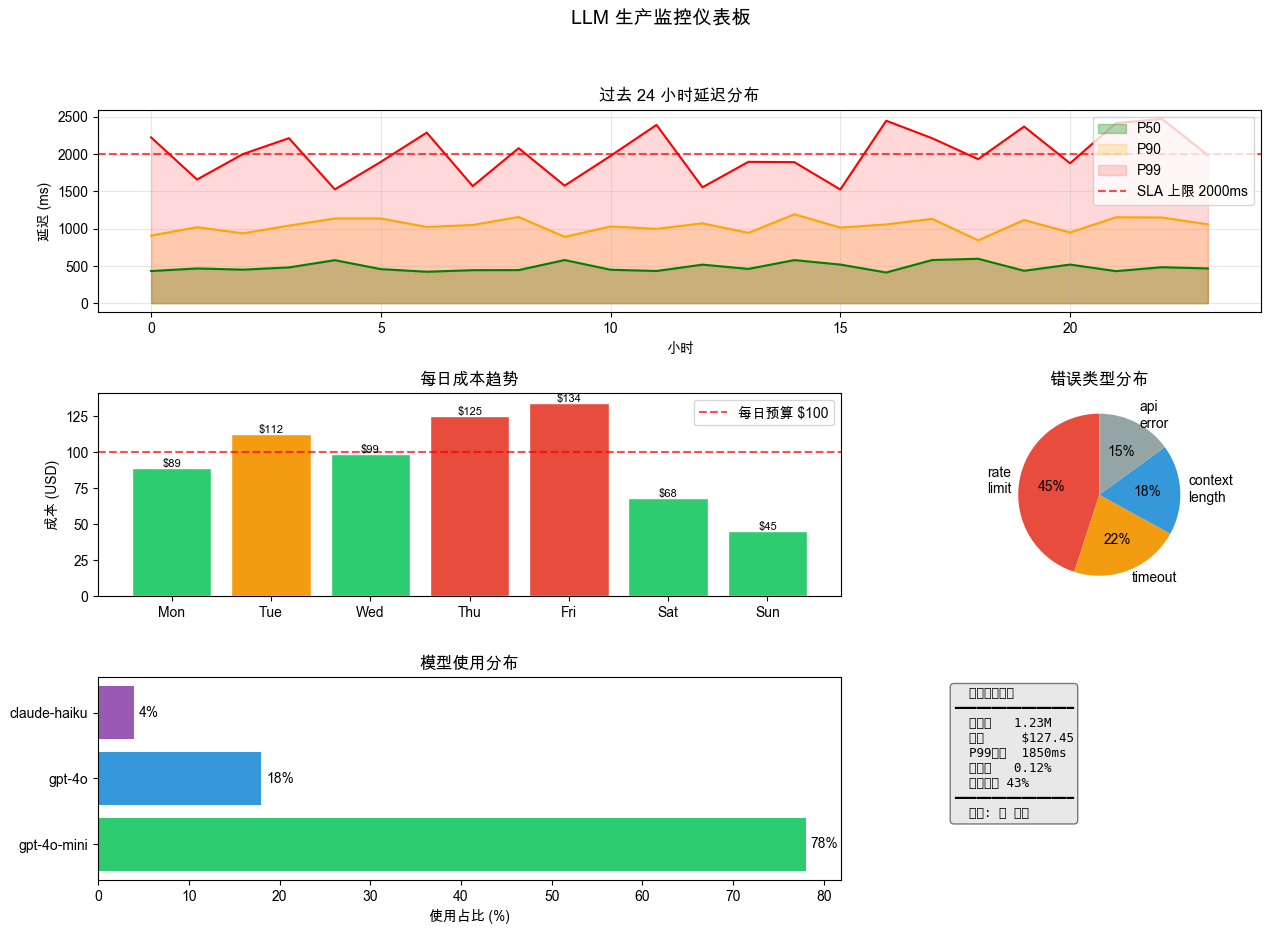

仪表板已保存到 /tmp/llm_dashboard.png


In [9]:
# 用 matplotlib 绘制简单的监控仪表板
try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import matplotlib
    matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    # 生成模拟数据
    hours = list(range(24))
    latency_p50 = [random.randint(400, 600) for _ in hours]
    latency_p90 = [random.randint(800, 1200) for _ in hours]
    latency_p99 = [random.randint(1500, 2500) for _ in hours]
    
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    daily_costs = [89.2, 112.4, 98.7, 125.3, 134.1, 67.8, 45.2]
    
    error_types = ["rate_limit", "timeout", "context_length", "api_error"]
    error_counts = [45, 22, 18, 15]
    
    model_names = ["gpt-4o-mini", "gpt-4o", "claude-haiku"]
    model_usage = [78, 18, 4]
    
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle("LLM 生产监控仪表板", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # 图1：延迟趋势
    ax1 = fig.add_subplot(gs[0, :])
    ax1.fill_between(hours, latency_p50, alpha=0.3, color="green", label="P50")
    ax1.fill_between(hours, latency_p90, alpha=0.2, color="orange", label="P90")
    ax1.fill_between(hours, latency_p99, alpha=0.15, color="red", label="P99")
    ax1.plot(hours, latency_p50, color="green", linewidth=1.5)
    ax1.plot(hours, latency_p90, color="orange", linewidth=1.5)
    ax1.plot(hours, latency_p99, color="red", linewidth=1.5)
    ax1.axhline(y=2000, color="red", linestyle="--", alpha=0.7, label="SLA 上限 2000ms")
    ax1.set_xlabel("小时")
    ax1.set_ylabel("延迟 (ms)")
    ax1.set_title("过去 24 小时延迟分布")
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)
    
    # 图2：每日成本
    ax2 = fig.add_subplot(gs[1, :2])
    colors_cost = ["#e74c3c" if c > 120 else "#f39c12" if c > 100 else "#2ecc71" for c in daily_costs]
    ax2.bar(days, daily_costs, color=colors_cost, edgecolor="white")
    ax2.axhline(y=100, color="red", linestyle="--", alpha=0.7, label="每日预算 $100")
    ax2.set_ylabel("成本 (USD)")
    ax2.set_title("每日成本趋势")
    ax2.legend()
    for bar, cost in zip(ax2.patches, daily_costs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"${cost:.0f}", ha="center", fontsize=8)
    
    # 图3：错误类型分布
    ax3 = fig.add_subplot(gs[1, 2])
    wedges, texts, autotexts = ax3.pie(
        error_counts,
        labels=[e.replace("_", "\n") for e in error_types],
        autopct="%1.0f%%",
        colors=["#e74c3c", "#f39c12", "#3498db", "#95a5a6"],
        startangle=90
    )
    ax3.set_title("错误类型分布")
    
    # 图4：模型使用分布
    ax4 = fig.add_subplot(gs[2, :2])
    bars = ax4.barh(model_names, model_usage, color=["#2ecc71", "#3498db", "#9b59b6"])
    ax4.set_xlabel("使用占比 (%)")
    ax4.set_title("模型使用分布")
    for bar, val in zip(bars, model_usage):
        ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=10)
    
    # 图5：关键指标卡片
    ax5 = fig.add_subplot(gs[2, 2])
    ax5.axis("off")
    metrics_text = (
        "  今日关键指标\n"
        "━━━━━━━━━━━━━━━━\n"
        "  调用量   1.23M\n"
        "  成本     $127.45\n"
        "  P99延迟  1850ms\n"
        "  错误率   0.12%\n"
        "  缓存命中 43%\n"
        "━━━━━━━━━━━━━━━━\n"
        "  状态: ✅ 健康"
    )
    ax5.text(0.05, 0.95, metrics_text, transform=ax5.transAxes,
             fontfamily="monospace", fontsize=9,
             verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.5))
    
    plt.savefig("/tmp/llm_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("仪表板已保存到 /tmp/llm_dashboard.png")

except ImportError:
    print("matplotlib 未安装，跳过仪表板可视化")
    print("安装：pip install matplotlib")

## Section 8：集成到现有系统

In [10]:
# 将所有组件集成为一个完整的 ObservabilityStack

class LLMObservabilityStack:
    """
    完整的 LLM 可观测性栈
    集成：日志 + 延迟追踪 + 成本追踪 + 错误监控
    
    使用方式：
        obs = LLMObservabilityStack(daily_budget=100)
        response = obs.completion(model=MODEL, messages=[...])
        obs.print_dashboard()
    """
    
    def __init__(self, daily_budget_usd: float = 100.0,
                  log_file: str = "/tmp/llm_obs.jsonl"):
        self.latency_tracker = LatencyTracker()
        self.cost_tracker = CostTracker(daily_budget_usd)
        self.error_monitor = ErrorMonitor()
        self.log_file = log_file
        self._call_count = 0
    
    def completion(self, model: str = None, messages: list = None,
                    request_id: str = None, **kwargs):
        """带完整可观测性的 completion"""
        model = model or MODEL
        request_id = request_id or str(uuid.uuid4())[:8]
        self._call_count += 1
        
        start = time.time()
        
        try:
            response = completion_with_retry(
                messages=messages,
                model=model,
                monitor=self.error_monitor,
                **kwargs
            )
            
            latency_ms = (time.time() - start) * 1000
            self.latency_tracker.record(latency_ms, model, request_id)
            self.cost_tracker.record(
                model,
                response.usage.prompt_tokens,
                response.usage.completion_tokens
            )
            
            # 写结构化日志
            log_entry = {
                "ts": datetime.now().isoformat(),
                "req_id": request_id,
                "model": model,
                "latency_ms": int(latency_ms),
                "prompt_tokens": response.usage.prompt_tokens,
                "completion_tokens": response.usage.completion_tokens,
                "status": "ok"
            }
            with open(self.log_file, "a") as f:
                f.write(json.dumps(log_entry) + "\n")
            
            return response
        
        except Exception as e:
            latency_ms = (time.time() - start) * 1000
            log_entry = {
                "ts": datetime.now().isoformat(),
                "req_id": request_id,
                "model": model,
                "latency_ms": int(latency_ms),
                "error": type(e).__name__,
                "status": "error"
            }
            with open(self.log_file, "a") as f:
                f.write(json.dumps(log_entry) + "\n")
            raise
    
    def print_dashboard(self):
        """打印即时仪表板"""
        lat = self.latency_tracker.stats()
        today_cost = self.cost_tracker.daily_cost()
        
        print("\n" + "═" * 55)
        print("  LLM 可观测性仪表板")
        print("═" * 55)
        print(f"  总调用次数:   {self._call_count}")
        print(f"  成功:         {self.error_monitor.success_count}")
        print(f"  错误:         {sum(self.error_monitor.error_counts.values())}")
        print(f"  错误率:       {self.error_monitor.error_rate:.2%}")
        print("  ─────────────── 延迟 ────────────────")
        if lat:
            print(f"  P50:  {lat['p50_ms']:>8.0f}ms")
            print(f"  P90:  {lat['p90_ms']:>8.0f}ms")
            print(f"  P99:  {lat['p99_ms']:>8.0f}ms")
        print("  ─────────────── 成本 ────────────────")
        print(f"  今日成本:     ${today_cost:.4f}")
        print(f"  预算上限:     ${self.cost_tracker.daily_budget:.2f}")
        print(f"  预算消耗:     {today_cost/self.cost_tracker.daily_budget:.0%}")
        print("═" * 55)


# 演示完整使用
obs = LLMObservabilityStack(daily_budget_usd=0.50)

print("使用集成可观测性栈进行 5 次调用：")
queries = ["什么是 Python", "解释 REST API", "什么是 Docker",
           "解释 Git 版本控制", "什么是 CI/CD"]

for i, q in enumerate(queries):
    response = obs.completion(
        model=MODEL,
        messages=[{"role": "user", "content": q}],
        max_tokens=40,
        temperature=0
    )
    print(f"  [{i+1}] {q[:30]:<30} → {response.choices[0].message.content[:40]}...")

obs.print_dashboard()

使用集成可观测性栈进行 5 次调用：


  [Callback] ✅ gpt-5-mini | 49tok | 1066ms
  [1] 什么是 Python                     → ...


  [Callback] ✅ gpt-5-mini | 49tok | 1127ms
  [2] 解释 REST API                    → ...


  [Callback] ✅ gpt-5-mini | 49tok | 984ms
  [3] 什么是 Docker                     → ...


  [Callback] ✅ gpt-5-mini | 51tok | 1042ms
  [4] 解释 Git 版本控制                    → ...


  [Callback] ✅ gpt-5-mini | 50tok | 988ms
  [5] 什么是 CI/CD                      → ...

═══════════════════════════════════════════════════════
  LLM 可观测性仪表板
═══════════════════════════════════════════════════════
  总调用次数:   5
  成功:         5
  错误:         0
  错误率:       0.00%
  ─────────────── 延迟 ────────────────
  P50:      1043ms
  P90:      1128ms
  P99:      1128ms
  ─────────────── 成本 ────────────────
  今日成本:     $0.0000
  预算上限:     $0.50
  预算消耗:     0%
═══════════════════════════════════════════════════════


## 总结：生产环境可观测性检查清单

### 上线前必须具备

- [ ] **结构化日志**：每次 LLM 调用记录 JSON 日志（时间戳、模型、tokens、延迟、状态）
- [ ] **错误处理**：所有 LLM 调用有 try-catch，区分可重试/不可重试错误
- [ ] **指数退避重试**：限流错误自动重试，避免雪崩
- [ ] **超时设置**：每个调用设置合理的 timeout（推荐 30-60s）

### 上线后持续监控

- [ ] **延迟告警**：P99 > 阈值时告警（通常 3-5s）
- [ ] **错误率告警**：错误率 > 1% 时告警
- [ ] **成本告警**：当日成本 > 预算 80% 时预警，> 100% 时告警
- [ ] **每日成本报告**：自动发送到 Slack/邮件

### 进阶监控

- [ ] **分布式追踪**：RAG/Agent 等多步骤流水线的完整 trace
- [ ] **缓存命中率**：监控语义缓存效果
- [ ] **模型使用分布**：各模型的调用比例
- [ ] **质量评估**：定期采样调用，运行 LLM-as-Judge 评估

### 推荐工具

| 场景 | 工具 | 说明 |
|------|------|------|
| LLM 专用追踪 | Langfuse | 开源，支持自托管 |
| 通用指标 | Prometheus + Grafana | 工业标准 |
| 日志存储 | Elasticsearch / ClickHouse | 高效查询大量日志 |
| 告警 | PagerDuty / OpsGenie | 智能告警路由 |
| APM | Datadog / Dynatrace | 全栈可观测性 |